# Test Classificatori su Dati Reali

Valutazione delle due versioni del classificatore fine-tunato ResNet-50:
| Versione | Livelli Scongelati |
|---|---|
| **Versione1** | Parziali (31%) |
| **Versione2** | Tutti |


#### Verifica dell'ambiente di lavoro

Viene calcolato il percorso base sulla base dell'ambiente di lavoro utilizzato (Locale o Google Colab)

In [1]:
import os
import sys

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/MammoDiffusion/'
else:
    print("Ambiente locale rilevato.")
    BASE_PATH = '../'

print(f"Percorso base: {BASE_PATH}")


Ambiente locale rilevato.
Percorso base: ../


#### Import librerie


In [2]:
import zipfile
import gdown
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    classification_report, precision_score, recall_score, f1_score
)

I0000 00:00:1781773814.858224   38205 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781773816.999113   38205 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781773822.174924   38205 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


#### Configurazione

In [ ]:
# Definizione percorsi degli esperimenti
REAL_SYNTH_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260617_real_synth_resnet50_fine_tuned_batch_size_16')
REAL_SYNTH_ALL_LAYERS_EXP_DIR = os.path.join(BASE_PATH, 'experiments', 'exp20260618_real_synth_resnet50_fine_tuned_all_layers')

# Salvataggio ID dei modelli salvati in Google Drive
REAL_SYNTH_MODEL_DRIVE_ID = '11f9pcL8kbLz7hi6i3lqDuferljdRl2uV'
REAL_SYNTH_ALL_LAYERS_MODEL_DRIVE_ID = '12lQfdsi3jWpfwIz8Q0ESAIoNzc8DNMqM'

# Salvataggio ID dei JSON contenenti le metriche calcolate sul validation set
REAL_SYNTH_METRICS_DRIVE_ID = '1J55coTQluAadvUsusaR2uzP5juNCYnKx'
REAL_SYNTH_ALL_LAYERS_METRICS_DRIVE_ID = '1yCfR9CmRLHn_y3gDTdpHKw214lGdFvhD'

# Definizione del Dataset di test
PROCESSED_DRIVE_ID = "1qQral_BIBlMl0QN3PllJukdYTOmNGWr3"
TEST_CSV_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'metadata', 'test.csv')

# Preprocessing
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])
AUTOTUNE = tf.data.AUTOTUNE

# Definizione cartelle di output (output risultati, figure, tabelle e predizioni)
OUTPUT_DIR      = os.path.join(BASE_PATH, 'results', 'test_classificatori_allVSpart')
FIGURES_DIR     = os.path.join(OUTPUT_DIR, 'figures')
TABLES_DIR      = os.path.join(OUTPUT_DIR, 'tables')
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, 'predictions')

for dir in (OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, PREDICTIONS_DIR):
    os.makedirs(dir, exist_ok=True)

print(f"Output salvato in: {OUTPUT_DIR}")
print(f"  figures/     => {FIGURES_DIR}")
print(f"  tables/      => {TABLES_DIR}")
print(f"  predictions/ => {PREDICTIONS_DIR}")

Output salvato in: ../results/test_classificatori_allVSpart
  figures/     => ../results/test_classificatori_allVSpart/figures
  tables/      => ../results/test_classificatori_allVSpart/tables
  predictions/ => ../results/test_classificatori_allVSpart/predictions


I0000 00:00:1781773833.183416   38205 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


#### Verifica Presenza Dataset Preprocessato

In [4]:
# Percorso dello zip del dataset preprocessato
PROCESSED_ZIP = os.path.join(BASE_PATH, 'data', 'processed', 'processed.zip')

def verifica_processed_data():
    if not os.path.isfile(TEST_CSV_PATH):
        return False
    try:
        first_path = pd.read_csv(TEST_CSV_PATH)['processed_path'].iloc[0]
        return os.path.isfile(os.path.join(BASE_PATH, first_path))
    except Exception:
        return False

if not verifica_processed_data():
    print("Dataset non trovato, scarico da Google Drive...")
    os.makedirs(os.path.dirname(PROCESSED_ZIP), exist_ok=True)
    gdown.download(id=PROCESSED_DRIVE_ID, output=PROCESSED_ZIP, quiet=False)
    with zipfile.ZipFile(PROCESSED_ZIP, 'r') as z:
        z.extractall(os.path.join(BASE_PATH, 'data', 'processed'))
    os.remove(PROCESSED_ZIP)
    print("Dataset estratto")
else:
    print("Dataset già presente, salto il download")


Dataset già presente, salto il download


#### Creazione Dataset di Test

Utilizzo del file `test.csv` del dataset preprocessato, che contiene le immagini mai viste durante il training né la validazione. Non viene utilizzata augmentation, solo preprocessing identico a quello utilizzato in training.

In [5]:
df_test = pd.read_csv(TEST_CSV_PATH).reset_index(drop=True)

n_positivi = (df_test['cancer'] == 1).sum()
n_negativi = (df_test['cancer'] == 0).sum()
print(f"Test set: {len(df_test)} immagini  (cancer=1: {n_positivi}, cancer=0: {n_negativi})")

def caricamento_preprocessing(percorso, etichetta):
    img_real = tf.io.read_file(percorso)
    img = tf.image.decode_image(img_real, channels=1, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.repeat(img, repeats=3, axis=-1)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img, tf.cast(etichetta, tf.float32)

def crea_dataset_test(df):
    percorsi  = [os.path.join(BASE_PATH, p) for p in df['processed_path'].values]
    etichette = df['cancer'].values
    ds = tf.data.Dataset.from_tensor_slices((percorsi, etichette))
    ds = ds.map(lambda p, l: caricamento_preprocessing(p, l), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = crea_dataset_test(df_test)
print("Dataset di test pronto")

Test set: 438 immagini  (cancer=1: 73, cancer=0: 365)
Dataset di test pronto


#### Caricamento Modelli

Logica di caricamento (in ordine di priorità):
1. Cartella esperimento locale (`experiments/exp.../`)
2. Cartella `results/test_classificatori/models/` (se scaricati in precedenza)
3. Download da Google Drive → salvato in `results/test_classificatori/models/`

In [6]:
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

MODELS_CONFIG = {
    'Real+Synth_Part': {
        'percorso_exp':   os.path.join(REAL_SYNTH_EXP_DIR, 'real_synth_resnet50_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,          'real_synth_resnet50_final_best.keras'),
        'drive_id':   REAL_SYNTH_MODEL_DRIVE_ID,
    },
    'Real+Synth_All_Layers': {
        'percorso_exp':   os.path.join(REAL_SYNTH_ALL_LAYERS_EXP_DIR, 'real_synth_resnet50_all_layers_final_best.keras'),
        'percorso_modello': os.path.join(MODELS_DIR,          'real_synth_resnet50_all_layers_final_best.keras'),
        'drive_id':   REAL_SYNTH_ALL_LAYERS_MODEL_DRIVE_ID,
    },
}

def caricamento_classificatore(nome_conf, config):
    # Cartella esperimento locale
    if os.path.isfile(config['percorso_exp']):
        print(f"[{nome_conf}] Carico dalla cartella esperimento")
        return keras.models.load_model(config['percorso_exp'])

    # Cache in results/models/
    if os.path.isfile(config['percorso_modello']):
        print(f"[{nome_conf}] Carico dalla cartella models")
        return keras.models.load_model(config['percorso_modello'])

    # Download da Drive
    print(f"[{nome_conf}] Modello non trovato localmente, scarico da Google Drive...")
    gdown.download(id=config['drive_id'], output=config['percorso_modello'], quiet=False)
    print(f"[{nome_conf}] Salvato in: {config['percorso_modello']}")
    return keras.models.load_model(config['percorso_modello'])

real_synth_model = caricamento_classificatore('Real+Synth_Part', MODELS_CONFIG['Real+Synth_Part'])
real_synth_all_layers_model = caricamento_classificatore('Real+Synth_All_Layers', MODELS_CONFIG['Real+Synth_All_Layers'])

print("\nTutti i modelli caricati.")

[Real+Synth_Part] Carico dalla cartella esperimento
[Real+Synth_All_Layers] Modello non trovato localmente, scarico da Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=12lQfdsi3jWpfwIz8Q0ESAIoNzc8DNMqM
From (redirected): https://drive.google.com/uc?id=12lQfdsi3jWpfwIz8Q0ESAIoNzc8DNMqM&confirm=t&uuid=23dac461-b796-4a2e-80d5-b7478e015d8c
To: /home/enzo/DeepLearning/MammoDiffusion/results/test_classificatori_allVSpart/models/real_synth_resnet50_all_layers_final_best.keras
100%|██████████| 290M/290M [00:17<00:00, 16.4MB/s] 


[Real+Synth_All_Layers] Salvato in: ../results/test_classificatori_allVSpart/models/real_synth_resnet50_all_layers_final_best.keras

Tutti i modelli caricati.


#### Caricamento Soglie Ottimali dal Validation Set

Le soglie ottimali (indice di Youden: J = TPR − FPR) sono state salvate in `val_metrics.json` durante il training.
Vengono utilizzate quelle per non essere ricalcolate sul set di test

Logica di caricamento (in ordine di priorità):
1. Cartella esperimento locale (`experiments/exp.../val_metrics.json`)
2. Cache in `results/test_classificatori/val_metrics/`
3. Download da Google Drive → salvato nella cartella val_metrics

In [7]:
VAL_METRICS_DIR = os.path.join(OUTPUT_DIR, 'val_metrics')
os.makedirs(VAL_METRICS_DIR, exist_ok=True)

METRICS_CONFIG = {
    'Real+Synth_Part': {
        'percorso_exp':   os.path.join(REAL_SYNTH_EXP_DIR, 'val_metrics.json'),
        'percorso_metriche': os.path.join(VAL_METRICS_DIR,     'real_synth_val_metrics.json'),
        'drive_id':   REAL_SYNTH_METRICS_DRIVE_ID,
    },
    'Real+Synth_All_Layers': {
        'percorso_exp':   os.path.join(REAL_SYNTH_ALL_LAYERS_EXP_DIR, 'val_metrics.json'),
        'percorso_metriche': os.path.join(VAL_METRICS_DIR,     'real_synth_all_layers_val_metrics.json'),
        'drive_id':   REAL_SYNTH_ALL_LAYERS_METRICS_DRIVE_ID,
    }
}

def load_val_metrics(nome, config):
    # Cartella esperimento locale
    if os.path.isfile(config['percorso_exp']):
        print(f"[{nome}] Carico val_metrics dalla cartella esperimento")
        with open(config['percorso_exp']) as f:
            return json.load(f)

    # Cache in results/val_metrics/
    if os.path.isfile(config['percorso_metriche']):
        print(f"[{nome}] Carico val_metrics dalla cartella metriche")
        with open(config['percorso_metriche']) as f:
            return json.load(f)

    # Download da Drive
    print(f"[{nome}] val_metrics.json non trovato, scarico da Google Drive...")
    gdown.download(id=config['drive_id'], output=config['percorso_metriche'], quiet=False)
    print(f"[{nome}] Salvato in: {config['percorso_metriche']}")
    with open(config['percorso_metriche']) as f:
        return json.load(f)

metriche_real_synth = load_val_metrics('Real+Synth_Part', METRICS_CONFIG['Real+Synth_Part'])
metriche_real_synth_all_layers = load_val_metrics('Real+Synth_All_Layers', METRICS_CONFIG['Real+Synth_All_Layers'])

real_synth_threshold = metriche_real_synth['optimal_threshold_youden']
real_synth_all_layers_threshold = metriche_real_synth_all_layers['optimal_threshold_youden']

print("\nSoglie ottimali (dal validation set):")
print(f"  Real+Synth_Part:        {real_synth_threshold:.3f}")
print(f"  Real+Synth_All_Layers:  {real_synth_all_layers_threshold:.3f}")

[Real+Synth_Part] Carico val_metrics dalla cartella esperimento
[Real+Synth_All_Layers] val_metrics.json non trovato, scarico da Google Drive...


Downloading...
From: https://drive.google.com/uc?id=1yCfR9CmRLHn_y3gDTdpHKw214lGdFvhD
To: /home/enzo/DeepLearning/MammoDiffusion/results/test_classificatori_allVSpart/val_metrics/real_synth_all_layers_val_metrics.json
100%|██████████| 654/654 [00:00<00:00, 902kB/s]

[Real+Synth_All_Layers] Salvato in: ../results/test_classificatori_allVSpart/val_metrics/real_synth_all_layers_val_metrics.json

Soglie ottimali (dal validation set):
  Real+Synth_Part:        0.269
  Real+Synth_All_Layers:  0.161


#### Predizioni sul Test Set

In [8]:
def predizioni_test_set(modello, dataset):
    y_true_list, y_prob_list = [], []
    for imgs, labels in dataset:
        probs = modello.predict(imgs, verbose=0)
        y_prob_list.extend(probs.flatten())
        y_true_list.extend(labels.numpy())
    return np.array(y_true_list), np.array(y_prob_list)

print("Predizioni Real+Synth_Part...")
y_true, real_synth_probs = predizioni_test_set(real_synth_model, test_ds)
print("Predizioni Real+Synth_All_Layers...")
_,      real_synth_all_layers_probs = predizioni_test_set(real_synth_all_layers_model, test_ds)
print("Predizioni completate")

Predizioni Real+Synth_Part...


I0000 00:00:1781774033.134844   38341 service.cc:153] XLA service 0x7a9fd4077100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781774033.134910   38341 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1781774033.317810   38341 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781774034.512019   38341 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1781774043.900700   38341 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Predizioni Real+Synth_All_Layers...
Predizioni completate


In [9]:
# Salvataggio predizioni in CSV
df_predizioni = df_test[['processed_path', 'cancer']].copy().rename(columns={'cancer': 'label_true'})

df_predizioni['prob_real_synth'] = real_synth_probs
df_predizioni['prob_real_synth_all_layers'] = real_synth_all_layers_probs


df_predizioni['pred_real_synth'] = (real_synth_probs >= real_synth_threshold).astype(int)
df_predizioni['pred_real_synth_all_layers'] = (real_synth_all_layers_probs >= real_synth_all_layers_threshold).astype(int)

preds_path = os.path.join(PREDICTIONS_DIR, 'test_predictions.csv')
df_predizioni.to_csv(preds_path, index=False)
print(f"Predizioni salvate in: {preds_path}")
print(df_predizioni.head())

Predizioni salvate in: ../results/test_classificatori_allVSpart/predictions/test_predictions.csv
                                     processed_path  label_true  \
0   data/processed/test/0/7400_1313640696_R_MLO.png           0   
1  data/processed/test/0/17622_1976237692_R_MLO.png           0   
2  data/processed/test/0/47787_1508162632_R_MLO.png           0   
3  data/processed/test/0/23982_1584070570_R_MLO.png           0   
4   data/processed/test/1/39611_177448093_L_MLO.png           1   

   prob_real_synth  prob_real_synth_all_layers  pred_real_synth  \
0         0.337121                    0.166795                1   
1         0.042136                    0.039052                0   
2         0.481765                    0.138532                1   
3         0.598339                    0.049915                1   
4         0.555150                    0.642907                1   

   pred_real_synth_all_layers  
0                           1  
1                           0  
2

#### Valutazione — Metriche per Configurazione

In [10]:
CLASSIFICATORI = {
    'Real+Synth_Part':       (real_synth_probs,            real_synth_threshold),
    'Real+Synth_All_Layers': (real_synth_all_layers_probs, real_synth_all_layers_threshold),
}

all_metrics = {}

for nome_conf, (probs, threshold) in CLASSIFICATORI.items():
    fpr, tpr, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)

    y_pred = (probs >= threshold).astype(int)

    all_metrics[nome_conf] = {
        'auc':       round(float(auc), 4),
        'threshold': round(float(threshold), 4),
        'accuracy':  round(float((y_pred == y_true).mean()), 4),
        'precision': round(float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'recall':    round(float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'f1':        round(float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)), 4),
        'fpr': fpr, 'tpr': tpr, 'y_pred': y_pred,
    }

    print(f"\n{'='*52}")
    print(f"  {nome_conf}")
    print(f"{'='*52}")
    print(f"  AUC:       {auc:.4f}")
    print(f"  Soglia:    {threshold:.3f}")
    print(f"  Accuracy:  {all_metrics[nome_conf]['accuracy']:.4f}")
    print(f"  Precision: {all_metrics[nome_conf]['precision']:.4f}")
    print(f"  Recall:    {all_metrics[nome_conf]['recall']:.4f}")
    print(f"  F1:        {all_metrics[nome_conf]['f1']:.4f}")
    print(classification_report(y_true, y_pred, target_names=['No cancro', 'Cancro']))

# Salva JSON in tables
metrics_to_save = {
    k: {m: v for m, v in vals.items() if m not in ('fpr', 'tpr', 'y_pred')}
    for k, vals in all_metrics.items()
}
test_metrics_path = os.path.join(TABLES_DIR, 'test_metrics.json')
with open(test_metrics_path, 'w') as f:
    json.dump(metrics_to_save, f, indent=2, ensure_ascii=False)
print(f"\nMetriche salvate in: {test_metrics_path}")


  Real+Synth_Part
  AUC:       0.6122
  Soglia:    0.269
  Accuracy:  0.5274
  Precision: 0.2035
  Recall:    0.6301
  F1:        0.3077
              precision    recall  f1-score   support

   No cancro       0.87      0.51      0.64       365
      Cancro       0.20      0.63      0.31        73

    accuracy                           0.53       438
   macro avg       0.54      0.57      0.47       438
weighted avg       0.76      0.53      0.59       438


  Real+Synth_All_Layers
  AUC:       0.6050
  Soglia:    0.161
  Accuracy:  0.5959
  Precision: 0.2174
  Recall:    0.5479
  F1:        0.3113
              precision    recall  f1-score   support

   No cancro       0.87      0.61      0.71       365
      Cancro       0.22      0.55      0.31        73

    accuracy                           0.60       438
   macro avg       0.54      0.58      0.51       438
weighted avg       0.76      0.60      0.65       438


Metriche salvate in: ../results/test_classificatori_allVSpart/t

#### Visualizzazione — ROC Curves a Confronto

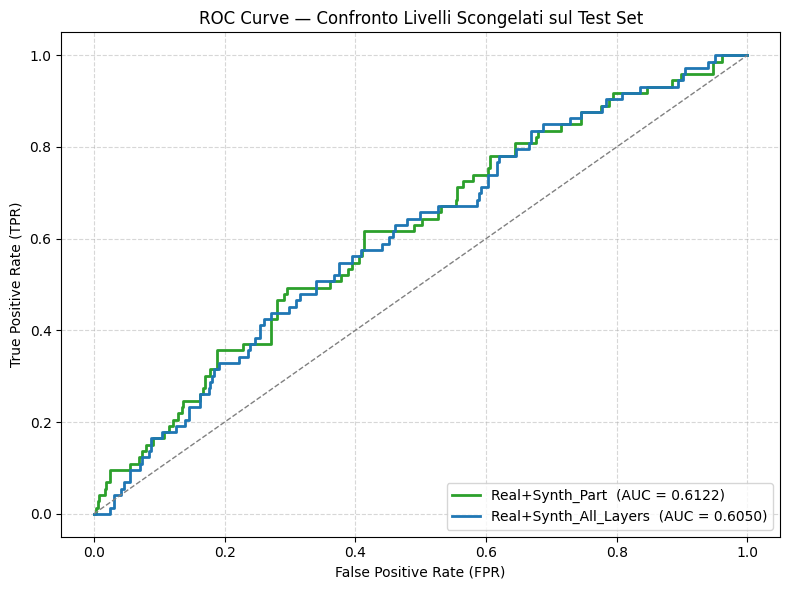

Salvato in: ../results/test_classificatori_allVSpart/figures/test_roc_curves.png


In [11]:
COLORS = {'Real+Synth_Part': 'tab:green', 'Real+Synth_All_Layers': 'tab:blue'}

fig, ax = plt.subplots(figsize=(8, 6))
for nome_conf, m in all_metrics.items():
    ax.plot(m['fpr'], m['tpr'], color=COLORS[nome_conf], lw=2,
            label=f"{nome_conf}  (AUC = {m['auc']:.4f})")

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR)')
ax.set_title('ROC Curve — Confronto Livelli Scongelati sul Test Set')
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
roc_path = os.path.join(FIGURES_DIR, 'test_roc_curves.png')
fig.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {roc_path}")

#### Visualizzazione — Matrici di confusione

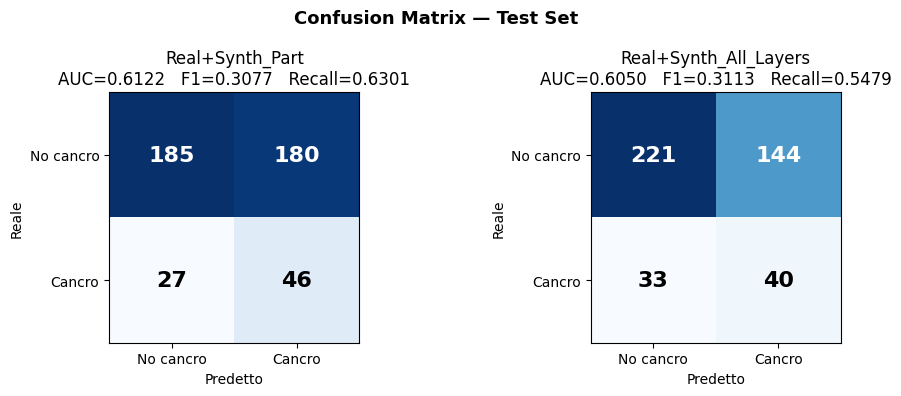

Salvato in: ../results/test_classificatori_allVSpart/figures/test_confusion_matrices.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nome_conf, m) in zip(axes, all_metrics.items()):
    cm = confusion_matrix(y_true, m['y_pred'])
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No cancro', 'Cancro'])
    ax.set_yticklabels(['No cancro', 'Cancro'])
    ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
    ax.set_title(f'{nome_conf}\nAUC={m["auc"]:.4f}   F1={m["f1"]:.4f}   Recall={m["recall"]:.4f}')
    for i in range(2):
        for j in range(2):
            color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    fontsize=16, fontweight='bold', color=color)

plt.suptitle('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(FIGURES_DIR, 'test_confusion_matrices.png')
fig.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {cm_path}")

#### Visualizzazione — Confronto Metriche

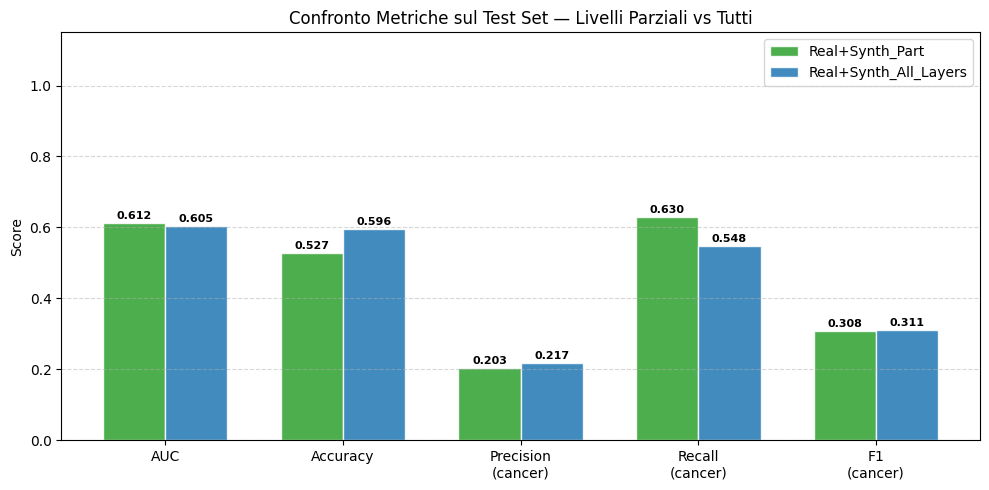

Salvato in: ../results/test_classificatori_allVSpart/figures/test_metrics_comparison.png


In [13]:
metric_keys   = ['auc', 'accuracy', 'precision', 'recall', 'f1']
metric_labels = ['AUC', 'Accuracy', 'Precision\n(cancer)', 'Recall\n(cancer)', 'F1\n(cancer)']

x = np.arange(len(metric_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
for i, (nome_conf, color) in enumerate(COLORS.items()):
    vals = [all_metrics[nome_conf][k] for k in metric_keys]
    bars = ax.bar(x + i * width, vals, width, label=nome_conf,
                  color=color, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Confronto Metriche sul Test Set — Livelli Parziali vs Tutti')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
bar_path = os.path.join(FIGURES_DIR, 'test_metrics_comparison.png')
fig.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {bar_path}")

#### Tabella Riassuntiva

In [14]:
df_risultati = pd.DataFrame([
    {
        'Configurazione': name,
        'AUC':       f"{m['auc']:.4f}",
        'Accuracy':  f"{m['accuracy']:.4f}",
        'Precision': f"{m['precision']:.4f}",
        'Recall':    f"{m['recall']:.4f}",
        'F1':        f"{m['f1']:.4f}",
        'Soglia':    f"{m['threshold']:.3f}",
    }
    for name, m in all_metrics.items()
]).set_index('Configurazione')

print(df_risultati.to_string())

percorso_tabella = os.path.join(TABLES_DIR, 'test_results_summary.csv')
df_risultati.to_csv(percorso_tabella)
print(f"\nTabella salvata in: {percorso_tabella}")

                          AUC Accuracy Precision  Recall      F1 Soglia
Configurazione                                                         
Real+Synth_Part        0.6122   0.5274    0.2035  0.6301  0.3077  0.269
Real+Synth_All_Layers  0.6050   0.5959    0.2174  0.5479  0.3113  0.161

Tabella salvata in: ../results/test_classificatori_allVSpart/tables/test_results_summary.csv


#### Grad-CAM — Confronto Attivazioni sul Test Set

Visualizziamo le regioni attivate dai tre classificatori sugli stessi campioni del test set (2 immagini cancro + 2 no-cancro).

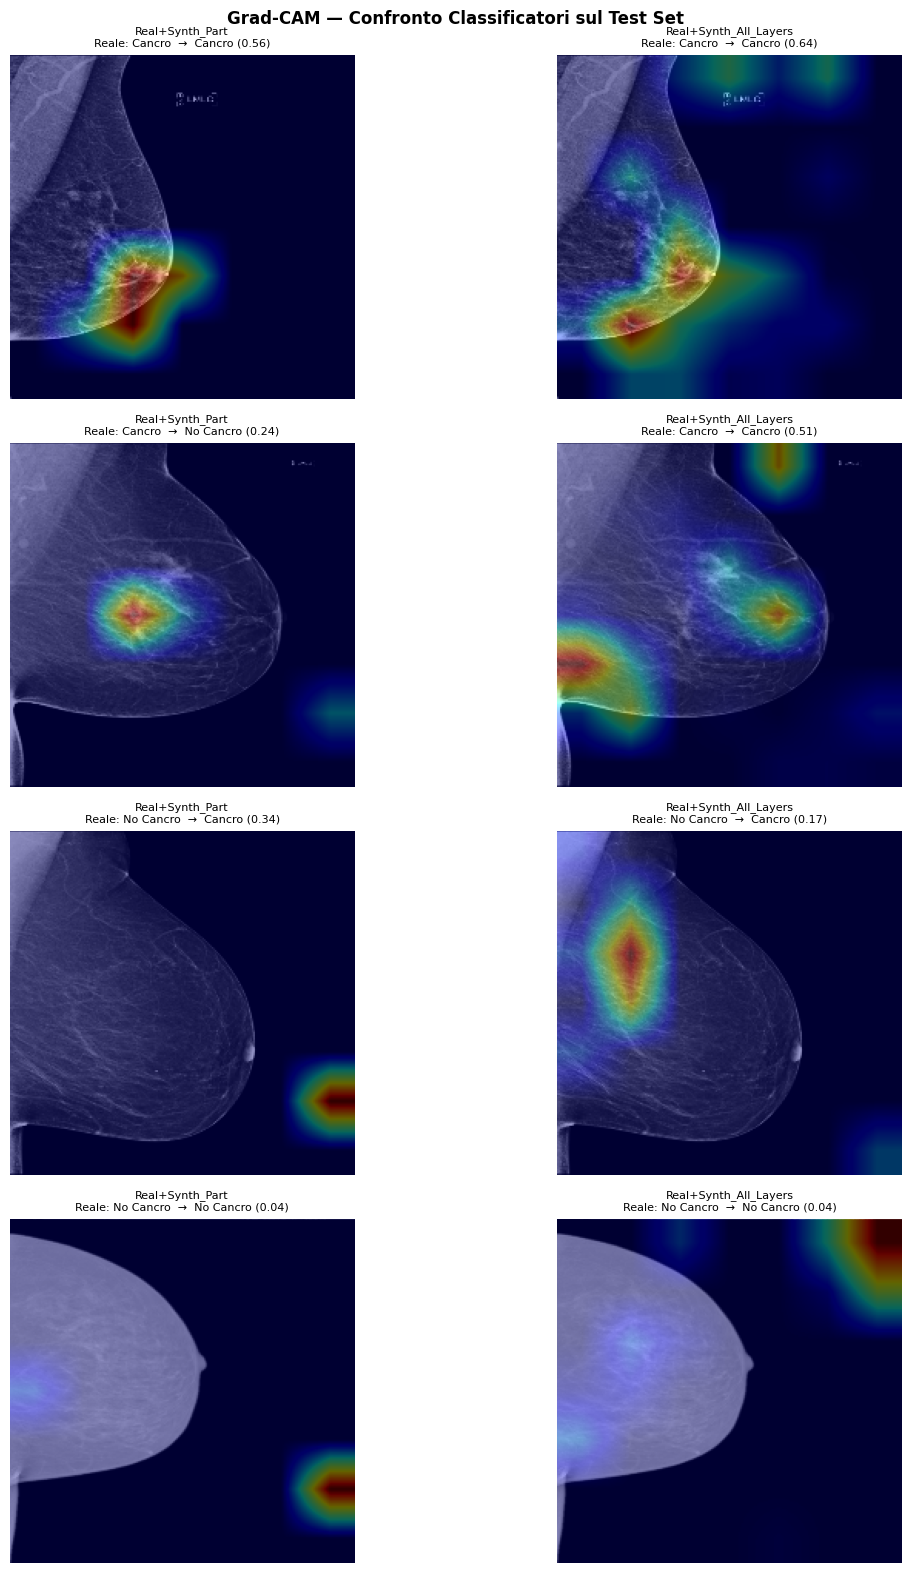

Salvato in: ../results/test_classificatori_allVSpart/figures/test_gradcam_comparison.png


In [15]:
IMAGENET_MEAN_NP = np.array([0.485, 0.456, 0.406])
IMAGENET_STD_NP  = np.array([0.229, 0.224, 0.225])

def make_gradcam_heatmap(img_array, model):
    backbone = model.get_layer('resnet50')
    head_layers = [l for l in model.layers
                   if l.name not in [model.layers[0].name, backbone.name]]
    with tf.GradientTape() as tape:
        backbone_out = backbone(img_array, training=False)
        tape.watch(backbone_out)
        x = backbone_out
        for layer in head_layers:
            x = layer(x, training=False)
        predictions = x
    grads = tape.gradient(predictions, backbone_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = backbone_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def show_gradcam(img_tensor, heatmap, ax, title=""):
    img_vis = img_tensor.numpy() * IMAGENET_STD_NP + IMAGENET_MEAN_NP
    img_vis = np.clip(img_vis, 0, 1)[:, :, 0]
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    ax.imshow(img_vis, cmap='gray')
    ax.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    ax.set_title(title, fontsize=8)
    ax.axis('off')

# Raccoglie 2 immagini cancro + 2 no-cancro dal test set
sample_pos, sample_neg = [], []
for imgs, etichette in test_ds:
    for i in range(len(imgs)):
        etichetta = int(etichette[i].numpy())
        if etichetta == 1 and len(sample_pos) < 2:
            sample_pos.append((imgs[i], etichetta))
        elif etichetta == 0 and len(sample_neg) < 2:
            sample_neg.append((imgs[i], etichetta))
    if len(sample_pos) >= 2 and len(sample_neg) >= 2:
        break

samples = sample_pos + sample_neg  # 4 campioni totali

classifiers_list = [
    ('Real+Synth_Part', real_synth_model, all_metrics['Real+Synth_Part']['threshold']),
    ('Real+Synth_All_Layers', real_synth_all_layers_model, all_metrics['Real+Synth_All_Layers']['threshold']),
]

fig, axes = plt.subplots(len(samples), len(classifiers_list), figsize=(13, 4 * len(samples)))
for row, (img, etichetta) in enumerate(samples):
    for col, (clf_name, clf_model, clf_thr) in enumerate(classifiers_list):
        img_batch = tf.expand_dims(img, 0)
        prob = float(clf_model.predict(img_batch, verbose=0)[0][0])
        pred = 'Cancro' if prob >= clf_thr else 'No Cancro'
        heatmap = make_gradcam_heatmap(img_batch, clf_model)
        show_gradcam(img, heatmap, axes[row, col],
                     title=f"{clf_name}\nReale: {'Cancro' if etichetta==1 else 'No Cancro'}  →  {pred} ({prob:.2f})")

plt.suptitle("Grad-CAM — Confronto Classificatori sul Test Set", fontsize=12, fontweight='bold')
plt.tight_layout()
gradcam_path = os.path.join(FIGURES_DIR, 'test_gradcam_comparison.png')
fig.savefig(gradcam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Salvato in: {gradcam_path}")